<a href="https://colab.research.google.com/github/Saehon/AAA/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# code for analysis text
# TODO: Add actual code for analysis here

In [25]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
texts = [
    "Audit risk is high in revenue recognition",
    "Key audit matters include goodwill impairment",
    "Cybersecurity risk affects financial reporting",
    "Management discusses internal control weakness"
]

In [26]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(texts)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Feature Names (Words):", vectorizer.get_feature_names_out())
print("\nTF-IDF Matrix (sparse format):\n", tfidf_matrix)

TF-IDF Matrix Shape: (4, 21)
Feature Names (Words): ['affects' 'audit' 'control' 'cybersecurity' 'discusses' 'financial'
 'goodwill' 'high' 'impairment' 'in' 'include' 'internal' 'is' 'key'
 'management' 'matters' 'recognition' 'reporting' 'revenue' 'risk'
 'weakness']

TF-IDF Matrix (sparse format):
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23 stored elements and shape (4, 21)>
  Coords	Values
  (0, 1)	0.3155366632994909
  (0, 19)	0.3155366632994909
  (0, 12)	0.4002182475169386
  (0, 7)	0.4002182475169386
  (0, 9)	0.4002182475169386
  (0, 18)	0.4002182475169386
  (0, 16)	0.4002182475169386
  (1, 1)	0.3325241986862672
  (1, 13)	0.4217647821447532
  (1, 15)	0.4217647821447532
  (1, 10)	0.4217647821447532
  (1, 6)	0.4217647821447532
  (1, 8)	0.4217647821447532
  (2, 19)	0.3667390112974172
  (2, 3)	0.4651619335222394
  (2, 0)	0.4651619335222394
  (2, 5)	0.4651619335222394
  (2, 17)	0.4651619335222394
  (3, 14)	0.4472135954999579
  (3, 4)	0.4472135954999579
  (3, 11)	0

In [27]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity
cosine_sim_matrix = cosine_similarity(tfidf_matrix)

print("\nCosine Similarity Matrix:\n", cosine_sim_matrix)


Cosine Similarity Matrix:
 [[1.         0.10492358 0.1157196  0.        ]
 [0.10492358 1.         0.         0.        ]
 [0.1157196  0.         1.         0.        ]
 [0.         0.         0.         1.        ]]


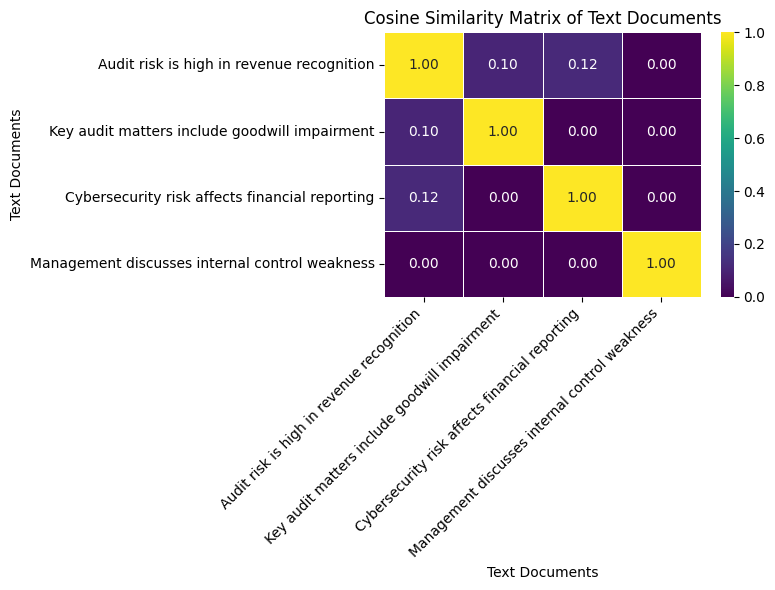

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for better labeling in the heatmap
import pandas as pd
similarity_df = pd.DataFrame(cosine_sim_matrix, index=texts, columns=texts)

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Cosine Similarity Matrix of Text Documents')
plt.xlabel('Text Documents')
plt.ylabel('Text Documents')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
import numpy as np

# Sum the TF-IDF scores for each feature (word) across all documents
word_tfidf_sums = np.asarray(tfidf_matrix.sum(axis=0)).ravel()

# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Create a pandas Series for easier sorting and viewing
word_frequencies = pd.Series(word_tfidf_sums, index=feature_names)

# Sort in descending order to find the most frequent words
most_frequent_words = word_frequencies.sort_values(ascending=False)

print("\nMost Frequently Occurring Words (by summed TF-IDF score):\n")
display(most_frequent_words.head(10)) # Display top 10 words


Most Frequently Occurring Words (by summed TF-IDF score):



,0
risk,0.682276
audit,0.648061
affects,0.465162
financial,0.465162
cybersecurity,0.465162
reporting,0.465162
control,0.447214
discusses,0.447214
internal,0.447214
weakness,0.447214


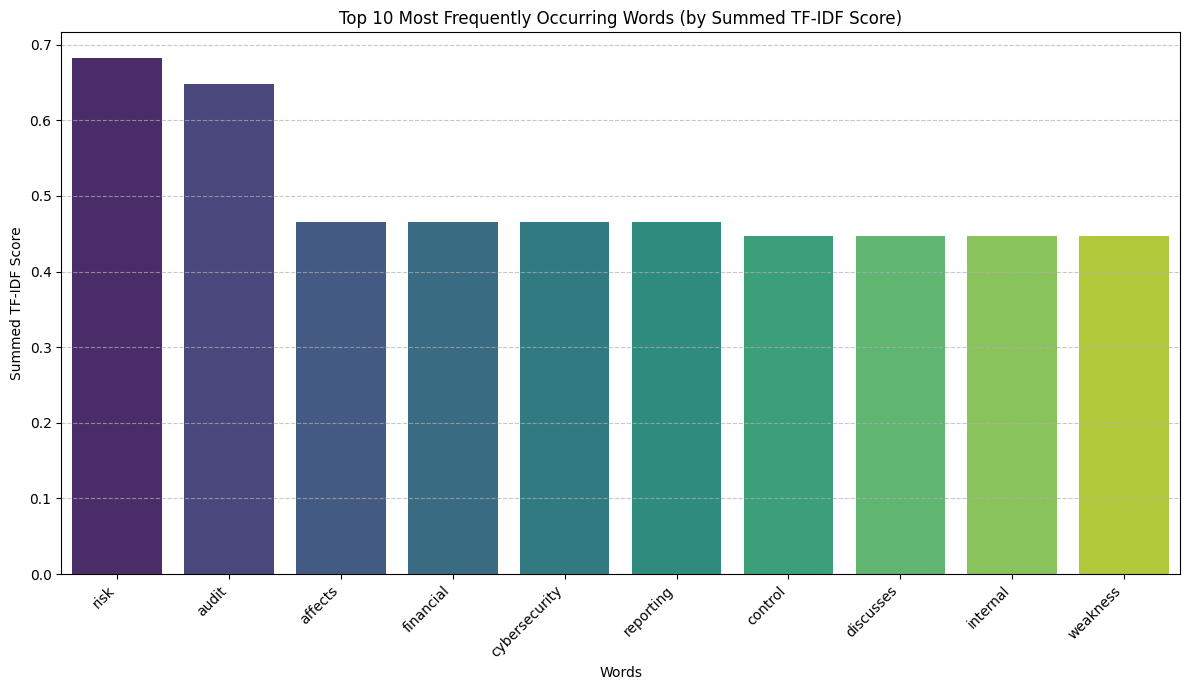

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=most_frequent_words.head(10).index, y=most_frequent_words.head(10).values, palette='viridis', hue=most_frequent_words.head(10).index, legend=False)
plt.title('Top 10 Most Frequently Occurring Words (by Summed TF-IDF Score)')
plt.xlabel('Words')
plt.ylabel('Summed TF-IDF Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd

# Create a DataFrame to represent our baseline 'KAM Evidence'
kam_evidence_baseline = pd.DataFrame({
    'kam_id': [f'KAM_{i+1:02d}' for i in range(len(texts))],
    'kam_statement': texts
})

print("Baseline 'KAM Evidence' Set:")
display(kam_evidence_baseline)

Baseline 'KAM Evidence' Set:


,kam_id,kam_statement
0,KAM_01,Audit risk is high in revenue recognition
1,KAM_02,Key audit matters include goodwill impairment
2,KAM_03,Cybersecurity risk affects financial reporting
3,KAM_04,Management discusses internal control weakness


Now that we have this `kam_evidence_baseline` DataFrame, here's how it fits into the 'Faithfulness' metric:

*   **KAM Evidence**: This DataFrame now *is* our baseline KAM evidence. Any new statements or documents would be evaluated against these `kam_statement` entries.

*   **Traceability**: For a new piece of text to be considered 'faithful' (i.e., 'supported-by-KAM evidence'), we would need to check if its content can be traced back to one or more statements in this `kam_evidence_baseline`. This could involve:
    *   **Semantic Similarity**: Using techniques like cosine similarity (which we've already calculated for other texts) to find which `kam_statement` in our baseline is most similar to the new text.
    *   **Keyword Matching**: Identifying if key terms from the new text are present and relevant in any `kam_statement`.
    *   **Entailment/Inference Models**: More advanced NLP models could determine if a new statement is logically entailed by (or can be inferred from) a `kam_statement`.

*   **Contradiction Penalty**: If a new text directly contradicts any of the `kam_statement` entries in our baseline, it would incur a penalty. Identifying contradictions is a complex NLP task, often requiring models capable of Natural Language Inference (NLI) to detect semantic opposition between statements.

To fully implement 'Faithfulness', the next step would be to define *what kind of new text* you want to evaluate and *how* you want to implement the 'traceability' and 'contradiction penalty' mechanisms against this `kam_evidence_baseline`.

### Calculate Faithfulness using Cosine Similarity

To evaluate the faithfulness of a new statement against the `kam_evidence_baseline`, we can calculate the cosine similarity between the new statement and each statement in the baseline. A higher cosine similarity score indicates a closer semantic relationship.

In [35]:
# Define the new sentence to evaluate
new_sentence = "The company is facing significant cybersecurity threats in its financial reporting."

# Extract existing KAM statements from the baseline DataFrame
kam_statements = kam_evidence_baseline['kam_statement'].tolist()

# Combine the new sentence with the KAM statements for vectorization
all_texts = kam_statements + [new_sentence]

# Re-vectorize all texts, including the new sentence
# We use the previously fitted vectorizer to ensure consistent vocabulary
combined_tfidf_matrix = vectorizer.fit_transform(all_texts)

# The new sentence is the last entry in the combined matrix
new_sentence_vector = combined_tfidf_matrix[-1]

# The KAM statements are the first n entries in the combined matrix
kam_vectors = combined_tfidf_matrix[:-1]

# Calculate cosine similarity between the new sentence and each KAM statement
similarities = cosine_similarity(new_sentence_vector, kam_vectors)

# Create a DataFrame to display the similarities
similarity_results_df = pd.DataFrame({
    'KAM_Statement': kam_statements,
    'Cosine_Similarity_to_New_Sentence': similarities.flatten()
})

display(similarity_results_df.sort_values(by='Cosine_Similarity_to_New_Sentence', ascending=False))

print(f"\nNew Sentence: '{new_sentence}'")

,KAM_Statement,Cosine_Similarity_to_New_Sentence
2,Cybersecurity risk affects financial reporting,0.338139
0,Audit risk is high in revenue recognition,0.180776
1,Key audit matters include goodwill impairment,0.000000
3,Management discusses internal control weakness,0.000000



New Sentence: 'The company is facing significant cybersecurity threats in its financial reporting.'


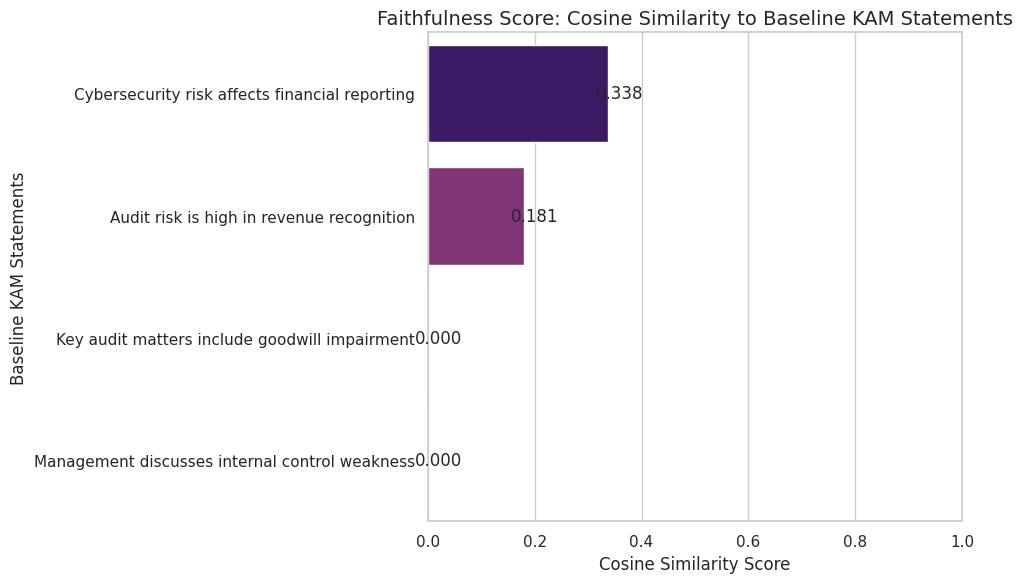

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create the bar chart
plt.figure(figsize=(10, 6))
sim_plot = sns.barplot(
    x="Cosine_Similarity_to_New_Sentence",
    y="KAM_Statement",
    data=similarity_results_df.sort_values(by="Cosine_Similarity_to_New_Sentence", ascending=False),
    palette="magma",
    hue="KAM_Statement",
    legend=False
)

# Add titles and labels
plt.title("Faithfulness Score: Cosine Similarity to Baseline KAM Statements", fontsize=14)
plt.xlabel("Cosine Similarity Score", fontsize=12)
plt.ylabel("Baseline KAM Statements", fontsize=12)
plt.xlim(0, 1)  # Similarity is bounded between 0 and 1

# Add data labels to the end of each bar
for p in sim_plot.patches:
    width = p.get_width()
    plt.text(width + 0.02, p.get_y() + p.get_height()/2, f'{width:.3f}', ha='center', va='center')

plt.tight_layout()
plt.show()

### Batch Similarity Analysis: Mean and Variance
We will now evaluate a set of multiple sentences to determine the average alignment (mean) and the spread of alignment (variance) across the dataset.

In [38]:
import numpy as np

# Define a set of new sentences
new_sentences = [
    "The company is facing significant cybersecurity threats in its financial reporting.",
    "Revenue recognition remains a key area of focus for the audit committee.",
    "Goodwill impairment was assessed and found to be immaterial this quarter.",
    "The weather in London is quite unpredictable during the spring.",
    "Internal controls over financial reporting have been strengthened."
]

# Vectorize the baseline again for consistency
kam_statements = kam_evidence_baseline['kam_statement'].tolist()
vectorizer = TfidfVectorizer()
kam_tfidf_matrix = vectorizer.fit_transform(kam_statements)

# Calculate max similarity score for each new sentence against any baseline entry
batch_scores = []
for sentence in new_sentences:
    sentence_vec = vectorizer.transform([sentence])
    # Get similarity against all baseline entries and take the maximum (best fit)
    sim_scores = cosine_similarity(sentence_vec, kam_tfidf_matrix).flatten()
    batch_scores.append(np.max(sim_scores))

# Calculate Statistics
mean_similarity = np.mean(batch_scores)
variance_similarity = np.var(batch_scores)

# Create a summary DataFrame
batch_results_df = pd.DataFrame({
    'New_Sentence': new_sentences,
    'Max_Similarity_Score': batch_scores
})

display(batch_results_df)
print(f"\nMean Similarity: {mean_similarity:.4f}")
print(f"Variance of Similarity: {variance_similarity:.4f}")

,New_Sentence,Max_Similarity_Score
0,The company is facing significant cybersecurit...,0.624080
1,Revenue recognition remains a key area of focu...,0.551331
2,Goodwill impairment was assessed and found to ...,0.596465
3,The weather in London is quite unpredictable d...,0.565994
4,Internal controls over financial reporting hav...,0.537123



Mean Similarity: 0.5750
Variance of Similarity: 0.0010


### Identifying the Variance Driver
To understand what is driving the variance in our batch results, we can look at the squared deviation of each score from the mean. The sentence with the highest deviation is the one most responsible for the spread in the data.

In [39]:
# Calculate squared deviations from the mean for each score
deviations = [(score - mean_similarity)**2 for score in batch_scores]

# Add to our results DataFrame
batch_results_df['Squared_Deviation'] = deviations

# Find the sentence with the maximum deviation
max_dev_idx = batch_results_df['Squared_Deviation'].idxmax()
variance_driver = batch_results_df.loc[max_dev_idx]

display(batch_results_df.sort_values(by='Squared_Deviation', ascending=False))

print(f"\nThe sentence causing the highest variance is:\n'{variance_driver['New_Sentence']}'")
print(f"Similarity Score: {variance_driver['Max_Similarity_Score']:.4f}")
print(f"Squared Deviation: {variance_driver['Squared_Deviation']:.6f}")

,New_Sentence,Max_Similarity_Score,Squared_Deviation
0,The company is facing significant cybersecurit...,0.624080,0.002409
4,Internal controls over financial reporting hav...,0.537123,0.001435
1,Revenue recognition remains a key area of focu...,0.551331,0.000560
2,Goodwill impairment was assessed and found to ...,0.596465,0.000461
3,The weather in London is quite unpredictable d...,0.565994,0.000081



The sentence causing the highest variance is:
'The company is facing significant cybersecurity threats in its financial reporting.'
Similarity Score: 0.6241
Squared Deviation: 0.002409


In [34]:
!pip install pandas scikit-learn nltk
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
texts = [
    "annly genscore for Audit risk is high in revenue recognition",
    "Key audit matters include goodwill impairment",
    "Cybersecurity risk affects financial reporting",
    "Management discusses internal control weakness"
]

In [21]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(texts)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Feature Names (Words):", vectorizer.get_feature_names_out())
print("\nTF-IDF Matrix (sparse format):\n", tfidf_matrix)

TF-IDF Matrix Shape: (4, 21)
Feature Names (Words): ['affects' 'audit' 'control' 'cybersecurity' 'discusses' 'financial'
 'goodwill' 'high' 'impairment' 'in' 'include' 'internal' 'is' 'key'
 'management' 'matters' 'recognition' 'reporting' 'revenue' 'risk'
 'weakness']

TF-IDF Matrix (sparse format):
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23 stored elements and shape (4, 21)>
  Coords	Values
  (0, 1)	0.3155366632994909
  (0, 19)	0.3155366632994909
  (0, 12)	0.4002182475169386
  (0, 7)	0.4002182475169386
  (0, 9)	0.4002182475169386
  (0, 18)	0.4002182475169386
  (0, 16)	0.4002182475169386
  (1, 1)	0.3325241986862672
  (1, 13)	0.4217647821447532
  (1, 15)	0.4217647821447532
  (1, 10)	0.4217647821447532
  (1, 6)	0.4217647821447532
  (1, 8)	0.4217647821447532
  (2, 19)	0.3667390112974172
  (2, 3)	0.4651619335222394
  (2, 0)	0.4651619335222394
  (2, 5)	0.4651619335222394
  (2, 17)	0.4651619335222394
  (3, 14)	0.4472135954999579
  (3, 4)	0.4472135954999579
  (3, 11)	0

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity
cosine_sim_matrix = cosine_similarity(tfidf_matrix)

print("\nCosine Similarity Matrix:\n", cosine_sim_matrix)


Cosine Similarity Matrix:
 [[1.         0.10492358 0.1157196  0.        ]
 [0.10492358 1.         0.         0.        ]
 [0.1157196  0.         1.         0.        ]
 [0.         0.         0.         1.        ]]


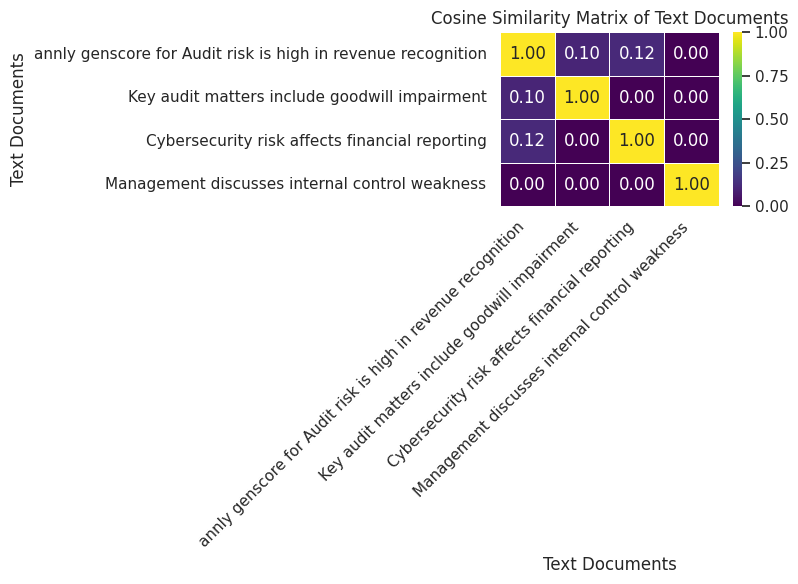

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for better labeling in the heatmap
import pandas as pd
similarity_df = pd.DataFrame(cosine_sim_matrix, index=texts, columns=texts)

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Cosine Similarity Matrix of Text Documents')
plt.xlabel('Text Documents')
plt.ylabel('Text Documents')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()